## Problem Statement
The goal is to predict the **median_house_value** in California based on features such as income level, housing age, population, and location. The objective is to build a machine learning model that can accurately estimate house prices, helping buyers, sellers, and policymakers make data-driven real estate decisions.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

In [30]:
df = pd.read_csv("/content/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Data Cleaning

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [32]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [33]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [34]:
df.dropna(inplace= True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

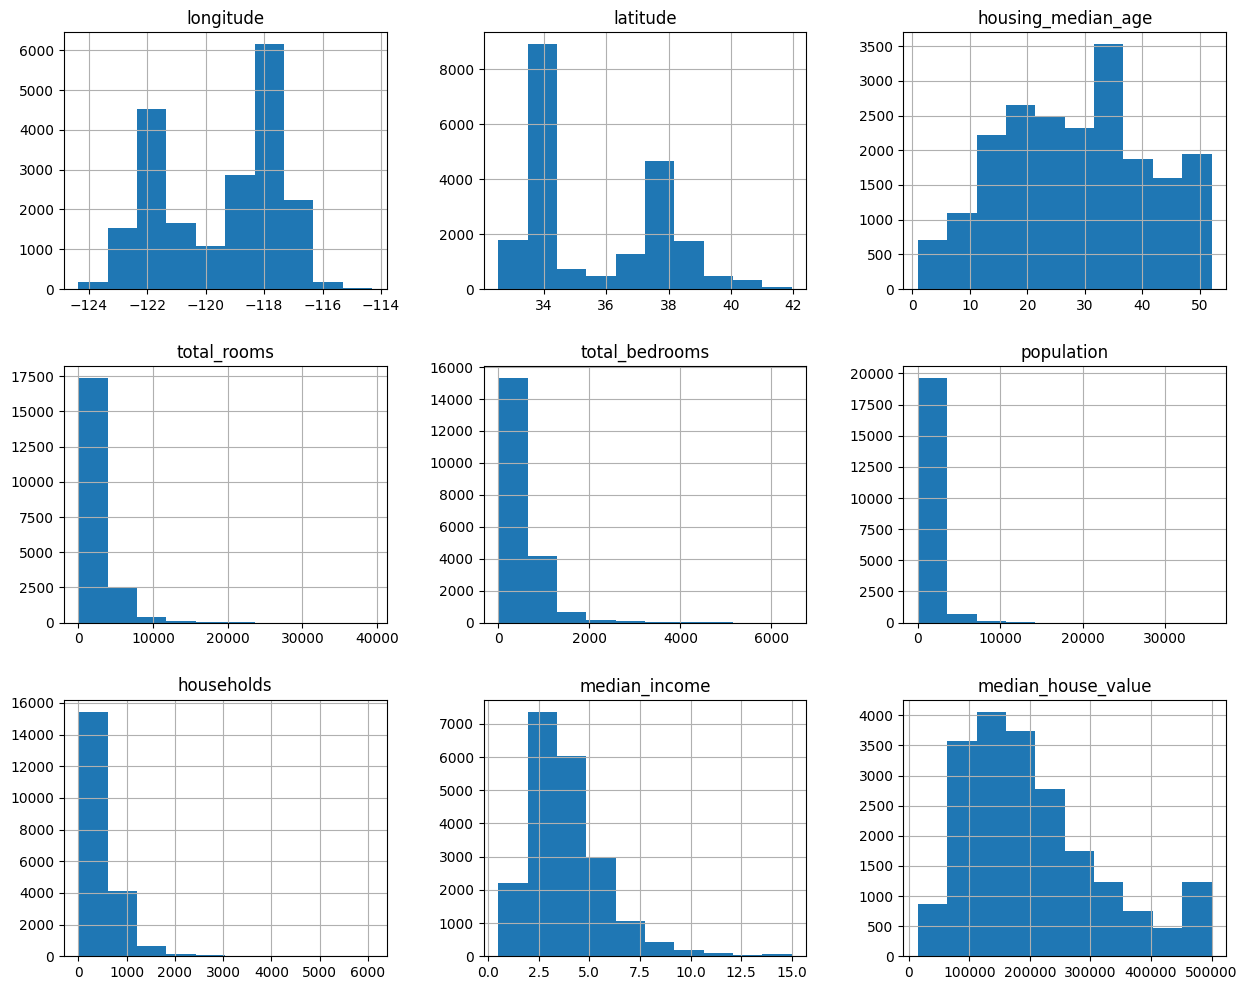

In [36]:
df.hist(figsize= (15,12))

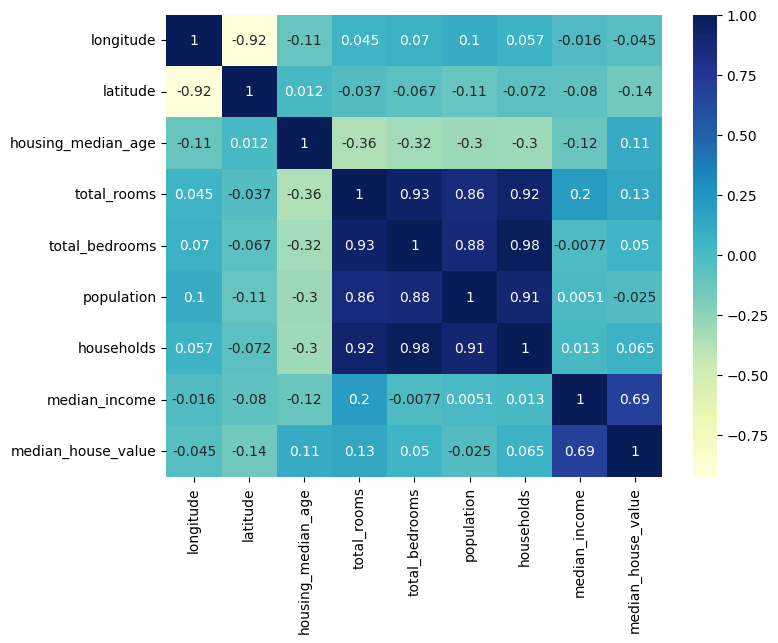

In [37]:
plt.figure(figsize= (8,6))
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap= 'YlGnBu')
# corr() error note:
# Use df.corr(numeric_only=True) to avoid “could not convert string to float” errors by excluding non-numeric columns.
plt.show()

`median_house_value` is highly correlated with `median_income`.

## Data Preprocessing

In [38]:
df['total_rooms'] = np.log(df['total_rooms'] + 1)
df['total_bedrooms'] = np.log(df['total_bedrooms'] + 1)
df['population'] = np.log(df['population'] + 1)
df['households'] = np.log(df['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

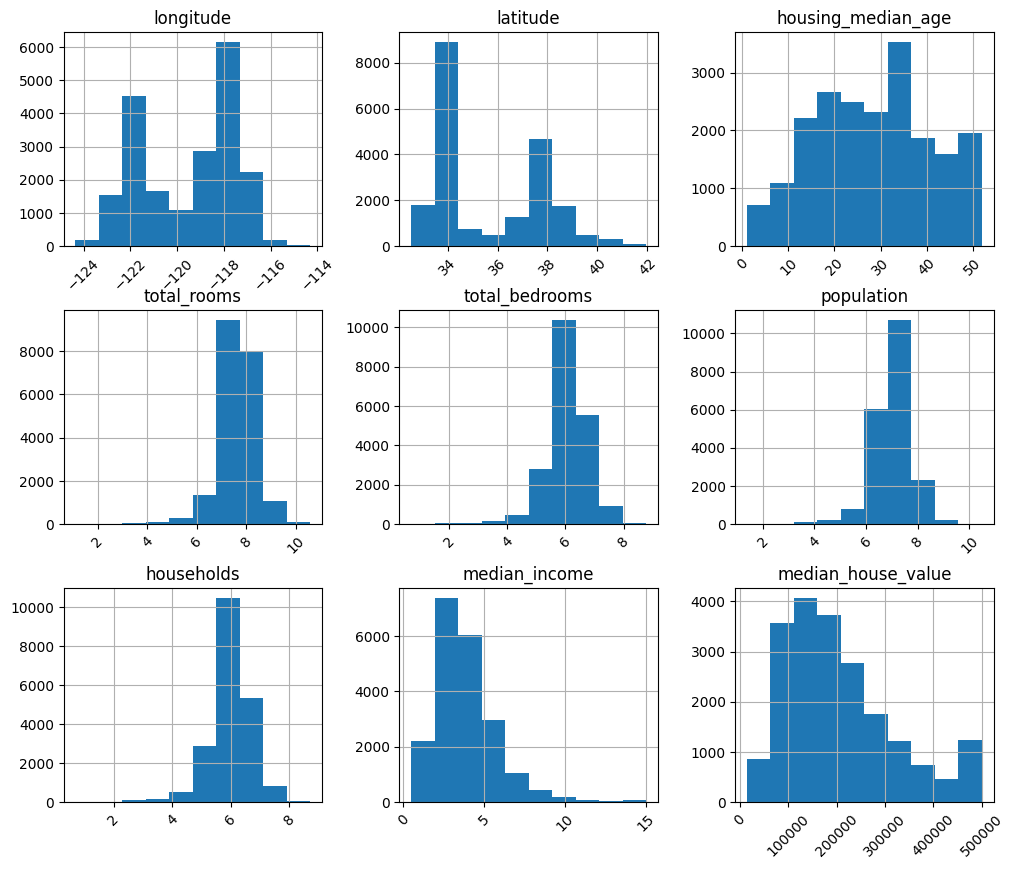

In [39]:
df.hist(figsize= (12,10), xrot= 45)

In [40]:
df.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [41]:
df = df.join(pd.get_dummies(df.ocean_proximity, dtype= 'int')).drop(['ocean_proximity'], axis = 1)
# get_dummies note:
# Use pd.get_dummies(df, columns=['col'], dtype=int) to create binary (0/1) dummy variables instead of True/False.

In [42]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.8672,84700.0,0,1,0,0,0


<Axes: >

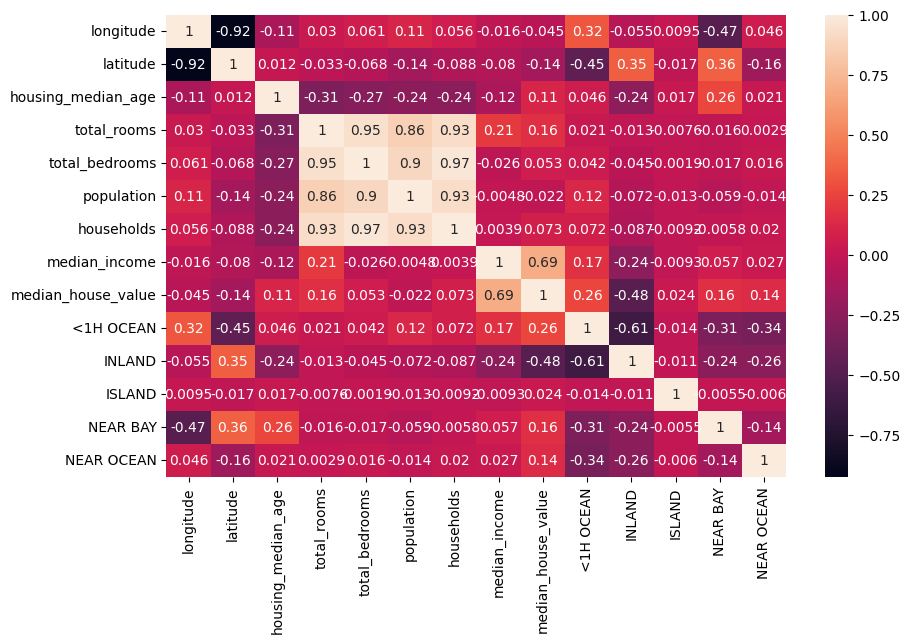

In [43]:
plt.figure(figsize= (10, 6))
sns.heatmap(df.corr(numeric_only= True), annot= True)

<Axes: xlabel='longitude', ylabel='latitude'>

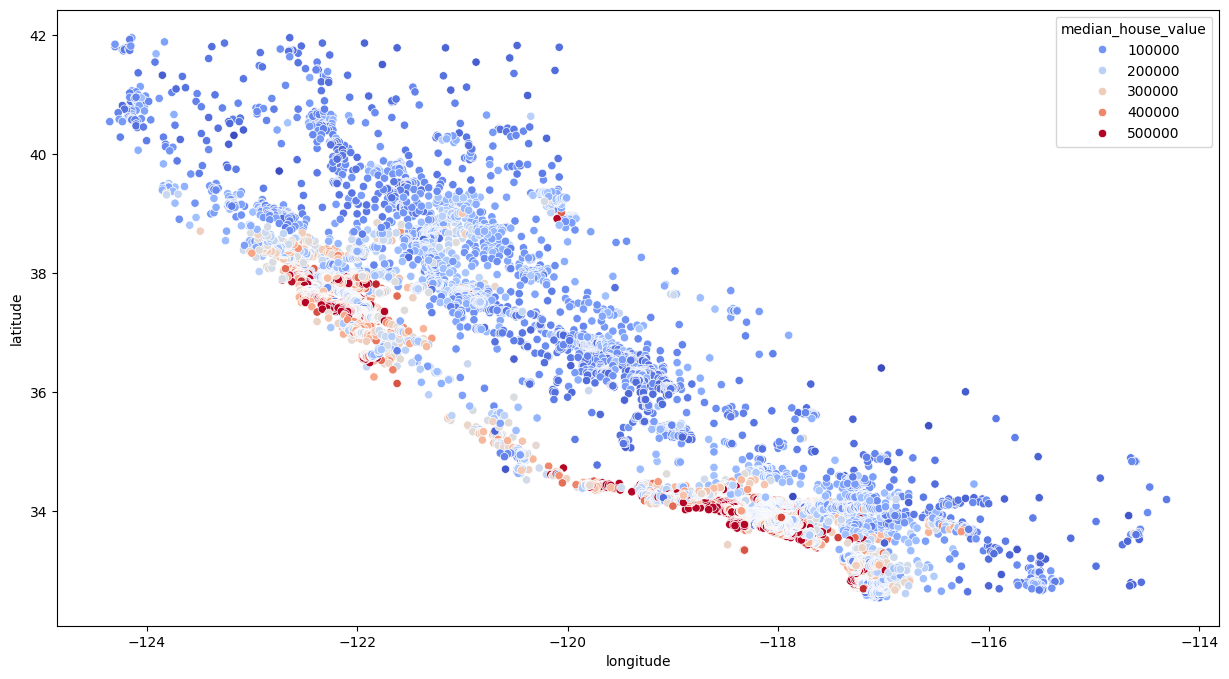

In [44]:
plt.figure(figsize= ( 15, 8))
sns.scatterplot(x = 'longitude', y = 'latitude', data = df, hue = 'median_house_value', palette= 'coolwarm')

The **red** color may indicate the island or near-water houses. Hence, price is **high**.

## Feature Engineering

In [45]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

>Ratio features (e.g., rooms_per_household, bedrooms_per_room) normalize scale and reveal density patterns that improve model learning even if direct correlation is small.

<Axes: >

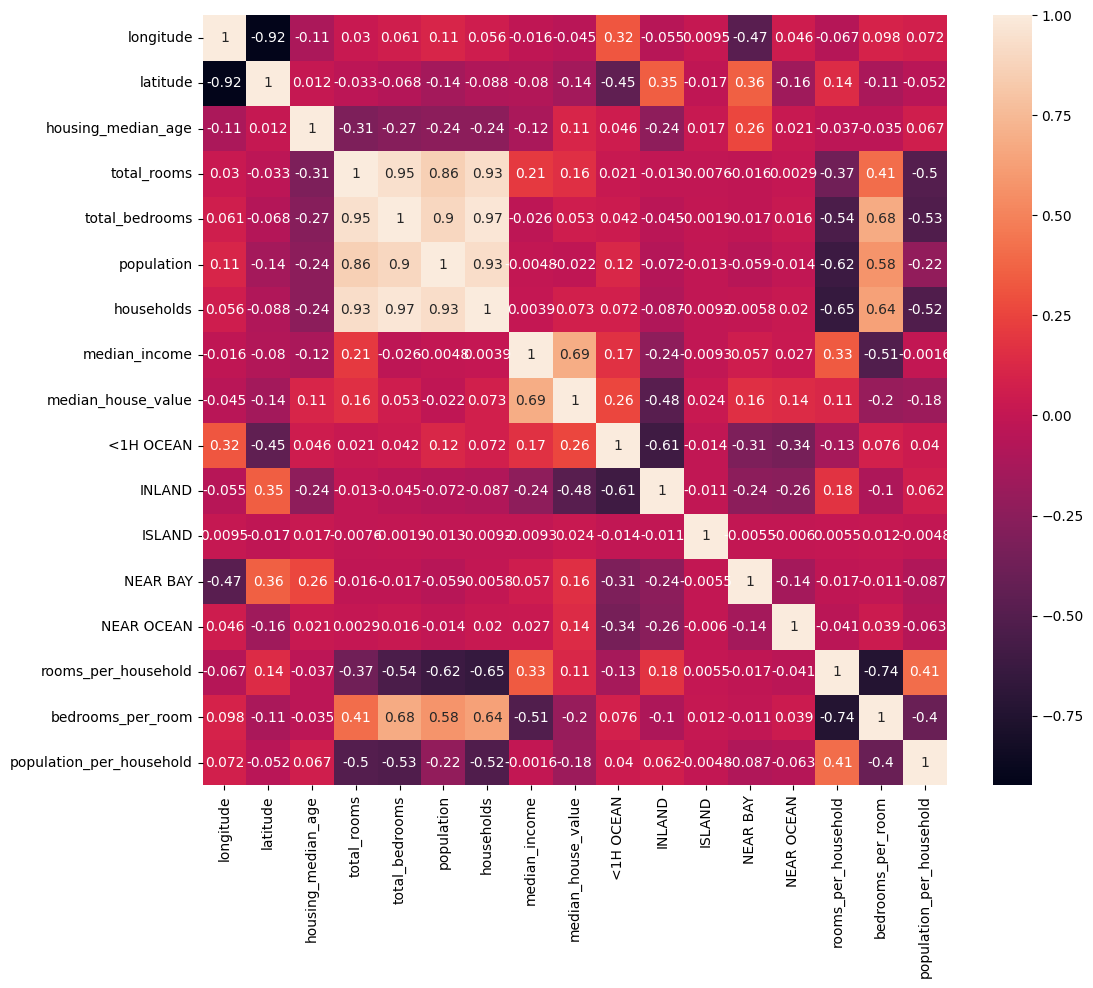

In [46]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only= True), annot= True)

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(['median_house_value'], axis = 1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [48]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
17985,-121.95,37.30,25.0,8.637994,7.325149,8.239329,7.252054,3.3958,1,0,0,0,0,1.191110,0.848015,1.136137
8233,-118.20,33.77,41.0,7.055313,5.983936,7.098376,5.820083,2.7813,0,0,0,0,1,1.212236,0.848146,1.219635
3803,-118.43,34.21,26.0,7.961370,6.510258,7.578657,6.463029,4.1250,1,0,0,0,0,1.231833,0.817731,1.172617
8879,-118.50,34.04,52.0,7.711549,5.762051,6.646391,5.627621,8.3839,1,0,0,0,0,1.370304,0.747198,1.181030
9201,-119.72,37.38,16.0,7.664816,6.052089,6.897705,5.913503,2.6071,0,1,0,0,0,1.296155,0.789594,1.166433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15112,-116.98,32.86,19.0,7.660114,5.834811,7.120444,5.869297,4.7717,1,0,0,0,0,1.305116,0.761713,1.213168
2895,-118.98,35.37,35.0,6.716595,5.192957,6.508769,5.204007,1.1638,0,1,0,0,0,1.290658,0.773153,1.250723
267,-122.19,37.77,52.0,7.753624,6.100319,7.043160,6.035481,3.5114,0,0,0,1,0,1.284674,0.786770,1.166959
12796,-121.45,38.63,28.0,7.128496,5.690359,6.785588,5.556828,1.4397,0,1,0,0,0,1.282835,0.798255,1.221126


## Model Building

In [49]:
# Linear Regression Model Training
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [50]:
reg.score(X_test, y_test)

0.6651043280458211

Linear Regression gives R² ≈ 0.67 because it **underfits** — it **assumes simple linear relationships** in a world that’s far more complex.

Models like Random Forest or Gradient Boosting capture those **nonlinear patterns** and push R² into the 0.80+ range.

In [51]:
# Random Forest Model Training
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [52]:
rf.score(X_test, y_test)

0.8059317699369836

## Model Evaluation

In [53]:
lr_score = reg.score(X_test, y_test)
rf_score = rf.score(X_test, y_test)

print("Linear Regression R2 Score:", lr_score)
print("Random Forest R2 Score:", rf_score)

Linear Regression R2 Score: 0.6651043280458211
Random Forest R2 Score: 0.8059317699369836


In [54]:
from sklearn.metrics import mean_squared_error
import numpy as np

lr_pred = reg.predict(X_test)
rf_pred = rf.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 66696.95738220536
Random Forest RMSE: 50772.49173073687


**Note:** Lower RMSE = better

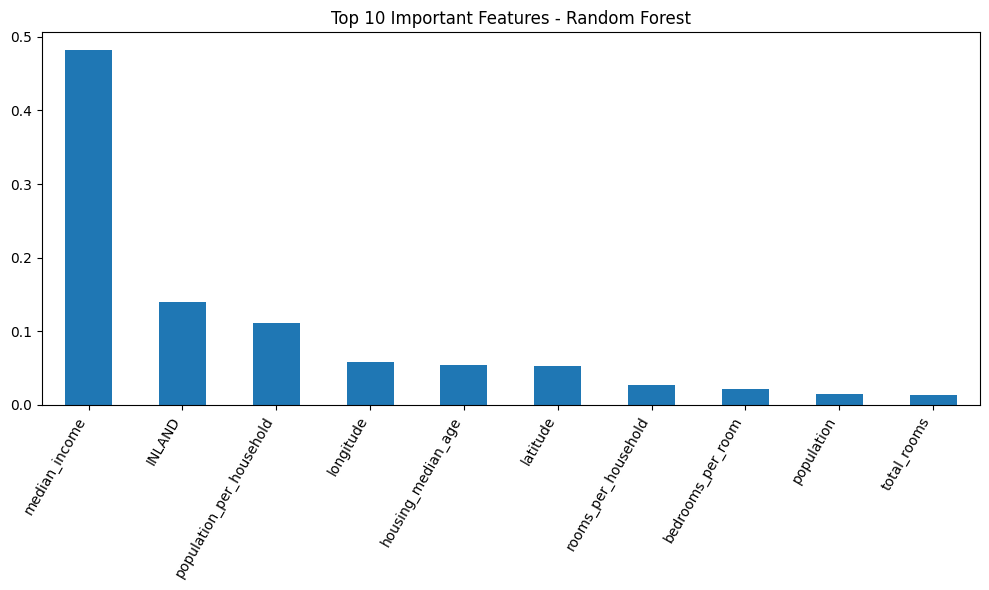

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar')

plt.title("Top 10 Important Features - Random Forest")
plt.xticks(rotation = 60, ha='right')
plt.tight_layout()
plt.show()

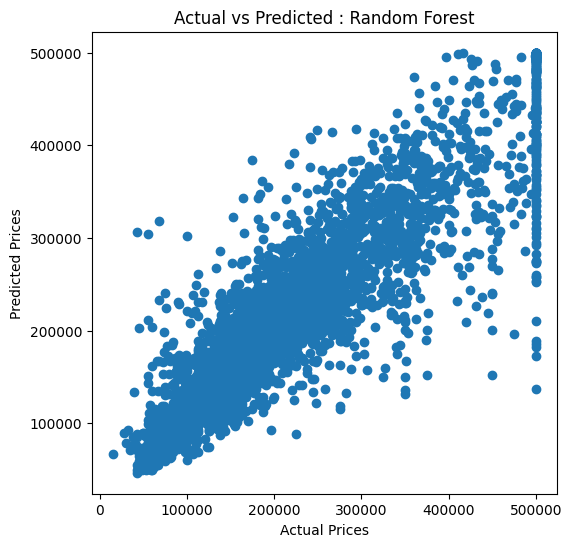

In [70]:
# Actual vs Predicted Price Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted : Random Forest")
plt.show()

As, points align diagonally ---> traits of a good model.

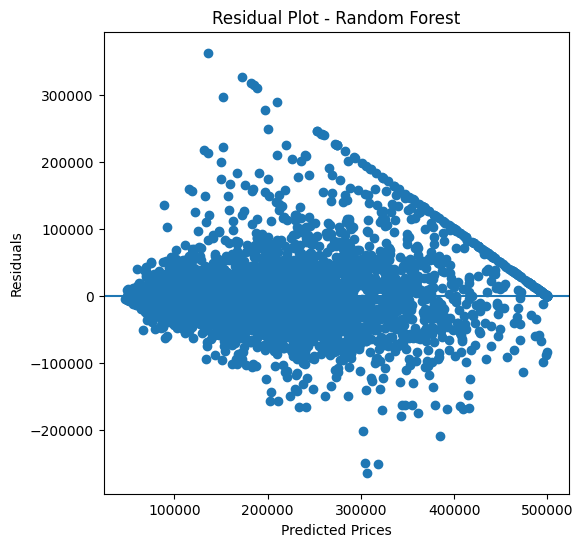

In [72]:
# Residual Analysis
residuals = y_test - rf_pred

plt.figure(figsize=(6,6))
plt.scatter(rf_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

As, residuals are randomly spread ---> model tends to be stable.

In [73]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation R2 Scores: [0.79879848 0.80154871 0.79593047 0.81570606 0.81066987]
Average CV Score: 0.8045307173531991


The scores are consistent across folds, with very little variation. </br>
This indicates that the **model performs reliably on different subsets** of the data and is NOT overfitting to a specific train-test split.

An average R² of 0.80 suggests that the model explains approximately 80% of the variance in house prices, demonstrating **strong predictive capability.**

## Model Comparison & Insights

- Random Forest achieved higher R2 score compared to Linear Regression.
> Linear Regression RMSE: 66696.95738220536 </br>
> Random Forest RMSE: 50772.49173073687

- RMSE was lower for Random Forest, indicating better prediction accuracy.
> Linear Regression RMSE: 66696.95738220536 </br>
> Random Forest RMSE: 50772.49173073687

- This suggests that house prices have non-linear relationships with features.
  
- Feature importance shows that variable like `median_income` strongly influence house price.

## Conclusion

This project built a model to estimate house prices in California using factors like income, housing details, and location. 

The final model gives good price estimates and performs better than a simple basic method. The results show that income level plays a very important role in determining house prices. 

Overall, the model can help people make better decisions when buying, selling, or studying housing trends.